In [ ]:
import pandas as pd
import joblib
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Tải 3 model tốt nhất và Vectorizer
tfidf = joblib.load('saved_models/tfidf_vectorizer.pkl')
best_lr = joblib.load('saved_models/best_lr.pkl')
best_rf = joblib.load('saved_models/best_rf.pkl')
best_xgb = joblib.load('saved_models/best_xgb.pkl')

# 2. Nạp 2 Đề thi
df_test_std = pd.read_csv('data/processed/test_standard.csv').dropna()
df_test_yt = pd.read_csv('data/processed/test_youtube.csv').dropna()

X_test_std = tfidf.transform(df_test_std['text_cleaned'])
X_test_yt = tfidf.transform(df_test_yt['text_cleaned'])

y_test_std = df_test_std['label']
y_test_yt = df_test_yt['label']

print(f"✅ Đã sẵn sàng thi đấu! Tập Test chuẩn: {len(df_test_std)} | Tập YouTube: {len(df_test_yt)}")

✅ Đã sẵn sàng thi đấu! Tập Test chuẩn: 996 | Tập YouTube: 957


In [ ]:
from sklearn.ensemble import VotingClassifier

# Khởi tạo mô hình biểu quyết (Soft Voting: dùng xác suất trung bình)
voting_model = VotingClassifier(
    estimators=[('lr', best_lr), ('rf', best_rf), ('xgb', best_xgb)],
    voting='soft'
)

# Lưu ý: VotingClassifier cần được fit lại (nhưng nó sẽ dùng tham số tối ưu đã có)
#  gộp Train + Val của File 1 để học lần cuối trước khi test YouTube
df_train = pd.read_csv('data/processed/train_final.csv')
df_val = pd.read_csv('data/processed/val_final.csv')
df_full = pd.concat([df_train, df_val], ignore_index=True).dropna()

X_train_full = tfidf.transform(df_full['text_cleaned'])
y_train_full = df_full['label']

print("--- ĐANG TRIỂN KHAI MÔ HÌNH BIỂU QUYẾT (VOTING) ---")
voting_model.fit(X_train_full, y_train_full)
print("✅ Mô hình Ensemble đã sẵn sàng!")

--- ĐANG TRIỂN KHAI MÔ HÌNH BIỂU QUYẾT (VOTING) ---
✅ Mô hình Ensemble đã sẵn sàng!


In [6]:
y_pred_std = voting_model.predict(X_test_std)
print("--- KẾT QUẢ TRÊN TẬP TEST CHUẨN (ViCTSD) ---")
print(f"Accuracy: {accuracy_score(y_test_std, y_pred_std)*100:.2f}%")
print(classification_report(y_test_std, y_pred_std))

--- KẾT QUẢ TRÊN TẬP TEST CHUẨN (ViCTSD) ---
Accuracy: 89.36%
              precision    recall  f1-score   support

           0       0.91      0.97      0.94       887
           1       0.53      0.25      0.34       109

    accuracy                           0.89       996
   macro avg       0.72      0.61      0.64       996
weighted avg       0.87      0.89      0.88       996



--- KẾT QUẢ THỰC CHIẾN YOUTUBE (Ngưỡng 0.42) ---
Accuracy: 59.98%
              precision    recall  f1-score   support

           0       0.68      0.78      0.73       652
           1       0.31      0.21      0.25       305

    accuracy                           0.60       957
   macro avg       0.49      0.50      0.49       957
weighted avg       0.56      0.60      0.57       957



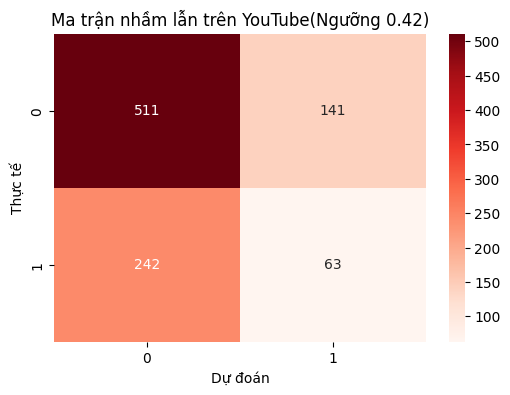

In [ ]:
import numpy as np

# 1. Lấy xác suất dự đoán lớp 1
y_probs_yt = voting_model.predict_proba(X_test_yt)[:, 1]

# 2. Chọn ngưỡng tối ưu (sau khi thử nghiệm, chọn 0.42 để cân bằng P và R)
t_opt = 0.42 
y_pred_yt_opt = (y_probs_yt >= t_opt).astype(int)

print(f"--- KẾT QUẢ THỰC CHIẾN YOUTUBE (Ngưỡng {t_opt}) ---")
print(f"Accuracy: {accuracy_score(y_test_yt, y_pred_yt_opt)*100:.2f}%")
print(classification_report(y_test_yt, y_pred_yt_opt))

# 3. Vẽ Confusion Matrix Heatmap
cm = confusion_matrix(y_test_yt, y_pred_yt_opt)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Reds')
plt.title('Ma trận nhầm lẫn trên YouTube(Ngưỡng 0.42)')
plt.ylabel('Thực tế')
plt.xlabel('Dự đoán')
plt.show()

In [31]:
# THỬ HẠ NGƯỠNG XUỐNG CỰC THẤP ĐỂ ÉP AI PHẢI BẮT ĐỘC HẠI
t_final = 0.28 
y_pred_final = (y_probs_yt >= t_final).astype(int)

print(f"--- KẾT QUẢ VỚI NGƯỠNG CHIẾN THUẬT: {t_final} ---")
print(classification_report(y_test_yt, y_pred_final))

--- KẾT QUẢ VỚI NGƯỠNG CHIẾN THUẬT: 0.28 ---
              precision    recall  f1-score   support

           0       0.69      0.62      0.65       652
           1       0.33      0.40      0.36       305

    accuracy                           0.55       957
   macro avg       0.51      0.51      0.51       957
weighted avg       0.57      0.55      0.56       957



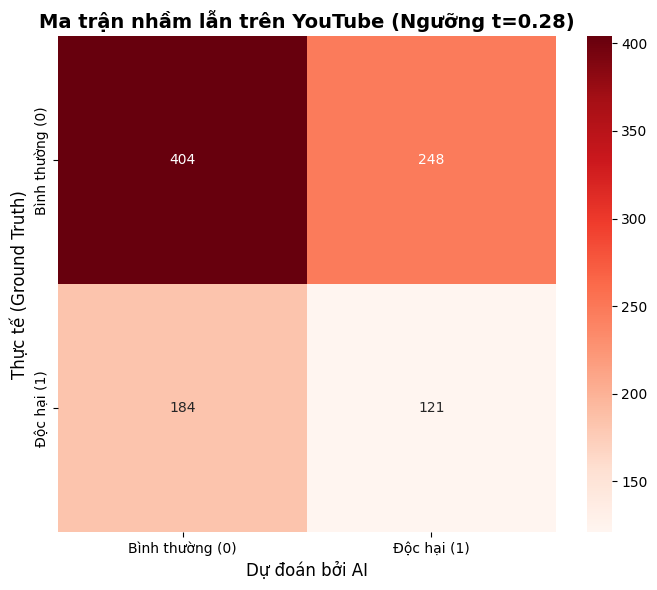

--- CHỈ SỐ CHI TIẾT TẠI NGƯỠNG 0.28 ---
              precision    recall  f1-score   support

           0       0.69      0.62      0.65       652
           1       0.33      0.40      0.36       305

    accuracy                           0.55       957
   macro avg       0.51      0.51      0.51       957
weighted avg       0.57      0.55      0.56       957



In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Áp dụng ngưỡng tối ưu 0.28 để lấy nhãn dự đoán cuối cùng 
t_final = 0.28
y_pred_final = (y_probs_yt >= t_final).astype(int)

# 2. Tính toán ma trận nhầm lẫn
cm = confusion_matrix(y_test_yt, y_pred_final)

# 3. Vẽ biểu đồ Heatmap
plt.figure(figsize=(7, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Reds', 
            xticklabels=['Bình thường (0)', 'Độc hại (1)'], 
            yticklabels=['Bình thường (0)', 'Độc hại (1)'])

plt.title(f'Ma trận nhầm lẫn trên YouTube (Ngưỡng t={t_final})', fontsize=14, fontweight='bold')
plt.ylabel('Thực tế (Ground Truth)', fontsize=12)
plt.xlabel('Dự đoán bởi AI', fontsize=12)



plt.tight_layout()
plt.show()

# 4. In lại báo cáo để lấy con số Precision/Recall dán kèm ảnh
from sklearn.metrics import classification_report
print(f"--- CHỈ SỐ CHI TIẾT TẠI NGƯỠNG {t_final} ---")
print(classification_report(y_test_yt, y_pred_final))

In [ ]:
import joblib
import os

# 1. Tạo thư mục saved_models nếu chưa có
if not os.path.exists('saved_models'):
    os.makedirs('saved_models')

# 2. LƯU MÔ HÌNH: Bạn phải dùng biến 'voting_model' 
joblib.dump(voting_model, 'saved_models/final_model.pkl')

# 3. LƯU VECTORIZER: 
joblib.dump(tfidf, 'saved_models/tfidf_vectorizer.pkl')

print("🚀 Đã lưu mô hình thành công vào thư mục saved_models!")

🚀 Đã lưu mô hình thành công vào thư mục saved_models!


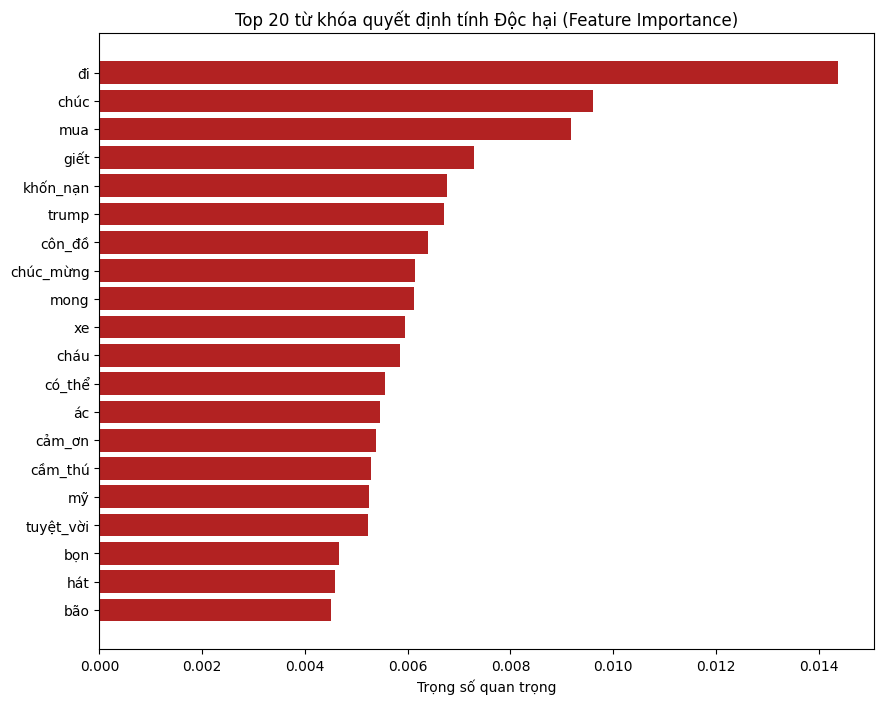

In [10]:
import matplotlib.pyplot as plt
import numpy as np

# Lấy trọng số từ mô hình Random Forest hoặc XGBoost trong Voting
# Ở đây ta lấy từ best_rf (ông giỏi nhất về đặc trưng)
importances = best_rf.feature_importances_
features = tfidf.get_feature_names_out()

# Sắp xếp và lấy top 20 từ quan trọng nhất
indices = np.argsort(importances)[-20:]

plt.figure(figsize=(10, 8))
plt.title('Top 20 từ khóa quyết định tính Độc hại (Feature Importance)')
plt.barh(range(len(indices)), importances[indices], color='firebrick', align='center')
plt.yticks(range(len(indices)), [features[i] for i in indices])
plt.xlabel('Trọng số quan trọng')
plt.show()

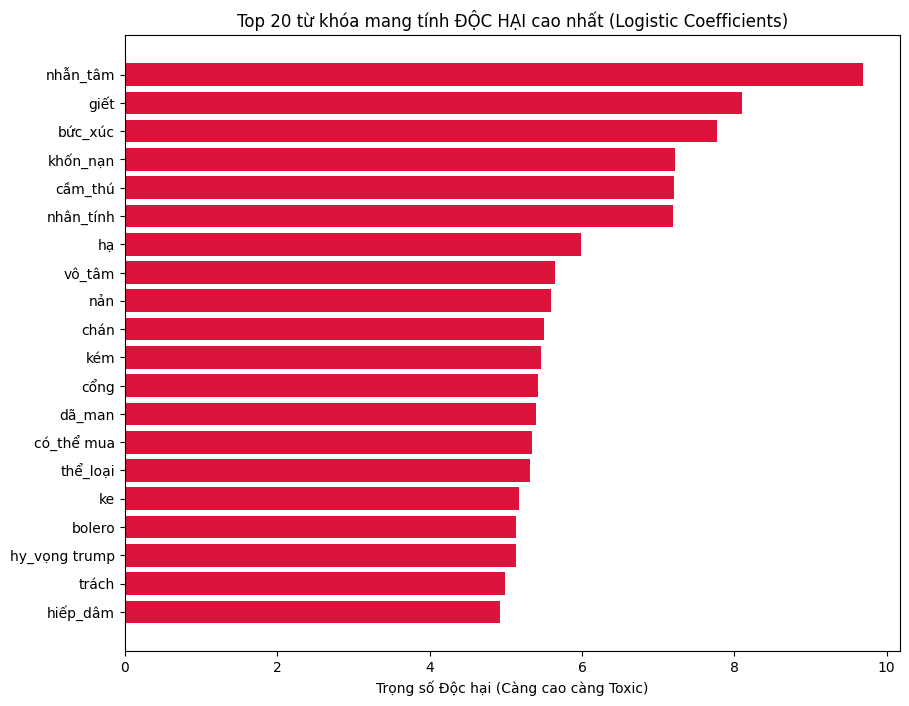

In [11]:
# Lấy trọng số từ mô hình Logistic Regression (vì nó có hướng âm/dương)
coefs = best_lr.coef_[0]
features = tfidf.get_feature_names_out()

# Chỉ lấy những từ có trọng số DƯƠNG cao nhất (đại diện cho lớp Độc hại)
top_toxic_indices = np.argsort(coefs)[-20:]

plt.figure(figsize=(10, 8))
plt.title('Top 20 từ khóa mang tính ĐỘC HẠI cao nhất (Logistic Coefficients)')
plt.barh(range(20), coefs[top_toxic_indices], color='crimson')
plt.yticks(range(20), [features[i] for i in top_toxic_indices])
plt.xlabel('Trọng số Độc hại (Càng cao càng Toxic)')
plt.show()

In [12]:
# Kiểm tra xem các từ trong Top 20 xuất hiện ở lớp nào nhiều hơn
def check_word_distribution(word, df):
    count_0 = df[df['text_cleaned'].str.contains(word, na=False) & (df['label'] == 0)].shape[0]
    count_1 = df[df['text_cleaned'].str.contains(word, na=False) & (df['label'] == 1)].shape[0]
    print(f"Từ '{word}': Lớp 0 (Sạch): {count_0} lần | Lớp 1 (Độc): {count_1} lần")

# Thử với vài từ "bình thường" trong biểu đồ của bạn
check_word_distribution('chúc', df_full)
check_word_distribution('tuyệt_vời', df_full)
check_word_distribution('khốn_nạn', df_full)

Từ 'chúc': Lớp 0 (Sạch): 441 lần | Lớp 1 (Độc): 7 lần
Từ 'tuyệt_vời': Lớp 0 (Sạch): 144 lần | Lớp 1 (Độc): 0 lần
Từ 'khốn_nạn': Lớp 0 (Sạch): 0 lần | Lớp 1 (Độc): 17 lần


In [28]:
import joblib
import re
from pyvi import ViTokenizer

# 1. PHẢI CÓ LẠI CÁC THÔNG TIN NÀY ĐỂ HÀM CLEAN HOẠT ĐỘNG
teencode_dict = {
    'cl': 'vãi lồn', 'vl': 'vãi lồn', 'vcl': 'vãi cả lồn', 'jv': 'gì vậy',
    'đ': 'được', 'đc': 'được', 'dc': 'được', 'ko': 'không', 'k': 'không',
    'đm': 'địt mẹ', 'dm': 'địt mẹ', 'đéo': 'đéo', 'rep': 'trả lời', 'ae': 'anh em'
}

def professional_clean(text):
    if not isinstance(text, str): return ""
    text = text.lower()
    text = re.sub(r'http\S+|www\S+|<[^>]+>', '', text)
    words = text.split()
    words = [teencode_dict.get(w, w) for w in words]
    text = ' '.join(words)
    text = re.sub(r'[^a-zàáãạảăắằẵặẳâấầẫậẩèéẹẻẽêềếệểễìíịỉĩòóọỏõôồốộổỗơờớợởỡùúụủũưừứựửữỳýỵỷỹđ0-9\s!?]', ' ', text)
    text = ViTokenizer.tokenize(text)
    words = text.split()
    clean_words = [w for w in words if len(w) > 1 or w in ['!', '?']]
    return ' '.join(clean_words).strip()

# 2. NẠP MÔ HÌNH VÀ VECTORIZER
final_model = joblib.load('saved_models/final_model.pkl')
tfidf = joblib.load('saved_models/tfidf_vectorizer.pkl')

# 3. HÀM DỰ ĐOÁN CHÍNH
def predict_toxic(text):
    cleaned_text = professional_clean(text)
    vectorized_text = tfidf.transform([cleaned_text])
    prob = final_model.predict_proba(vectorized_text)[:, 1][0]
    
    # Dùng đúng Threshold 0.28 bạn đã tối ưu
    threshold = 0.28
    label = 1 if prob >= threshold else 0
    
    status = "⚠️ ĐỘC HẠI" if label == 1 else "✅ BÌNH THƯỜNG"
    print(f"Nội dung: {text}")
    print(f"Xác suất độc hại: {prob*100:.1f}%")
    print(f"Kết quả phân loại: {status}")
    print("-" * 50)

# --- TEST THỬ ---
predict_toxic("Nhạc hay quá, chúc mừng anh!")
predict_toxic("k bít nói j lun á, đỉnh vcl")
predict_toxic("Cái bọn 3/ phản động")
predict_toxic("đm thằng ngu này")
predict_toxic("Mấy đứa chơi pickleball rác rưởi")




Nội dung: Nhạc hay quá, chúc mừng anh!
Xác suất độc hại: 23.8%
Kết quả phân loại: ✅ BÌNH THƯỜNG
--------------------------------------------------
Nội dung: k bít nói j lun á, đỉnh vcl
Xác suất độc hại: 8.5%
Kết quả phân loại: ✅ BÌNH THƯỜNG
--------------------------------------------------
Nội dung: Cái bọn 3/ phản động
Xác suất độc hại: 75.4%
Kết quả phân loại: ⚠️ ĐỘC HẠI
--------------------------------------------------
Nội dung: đm thằng ngu này
Xác suất độc hại: 23.7%
Kết quả phân loại: ✅ BÌNH THƯỜNG
--------------------------------------------------
Nội dung: Mấy đứa chơi pickleball rác rưởi
Xác suất độc hại: 18.2%
Kết quả phân loại: ✅ BÌNH THƯỜNG
--------------------------------------------------


C:\Users\ASUS\AppData\Local\Temp\ipykernel_13672\388201603.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=label_counts.index, y=label_counts.values, palette='viridis')


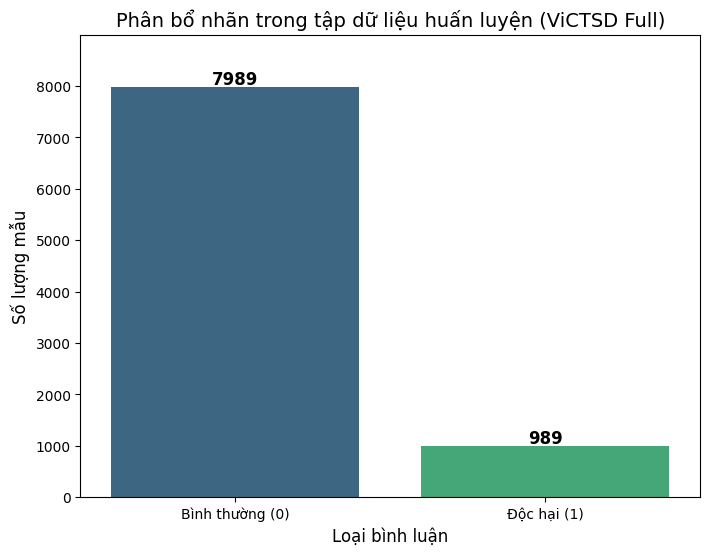

In [37]:
import seaborn as sns
import matplotlib.pyplot as plt

# Tính toán số lượng nhãn
label_counts = df_full['label'].value_counts()
label_names = ['Bình thường (0)', 'Độc hại (1)']

plt.figure(figsize=(8, 6))
# Vẽ biểu đồ cột
ax = sns.barplot(x=label_counts.index, y=label_counts.values, palette='viridis')

# Thêm số lượng cụ thể lên đầu mỗi cột
for i, v in enumerate(label_counts.values):
    ax.text(i, v + 50, str(v), ha='center', fontweight='bold', fontsize=12)

plt.title('Phân bổ nhãn trong tập dữ liệu huấn luyện (ViCTSD Full)', fontsize=14)
plt.xlabel('Loại bình luận', fontsize=12)
plt.ylabel('Số lượng mẫu', fontsize=12)
plt.xticks(ticks=[0, 1], labels=label_names)
plt.ylim(0, max(label_counts.values) + 1000) # Tạo khoảng trống phía trên cho đẹp
plt.show()